# Iteración 1: Modelo Prophet para Predicción de Gastos

Este cuaderno implementa el modelo **Prophet** de Meta (Facebook). Es ideal para este caso porque maneja automáticamente estacionalidades fuertes (como los gastos/ingresos de verano) y permite incluir variables adicionales (regresores exógenos) como los ingresos.

## Objetivo
Predecir los gastos futuros basándonos en el histórico de gastos y en los ingresos.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

### 1. Carga y Limpieza de Datos

In [5]:
# Cargar datos
file_path = '../data/raw/db_orig.csv'
df = pd.read_csv(file_path)

# Limpieza de la columna Amount
df['Amount'] = df['Amount'].str.replace('€', '', regex=False)
df['Amount'] = df['Amount'].str.replace('.', '', regex=False)
df['Amount'] = df['Amount'].str.replace(',', '.', regex=False)
df['Amount'] = pd.to_numeric(df['Amount'])

# Convertir fecha
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

display(df.head())

,Description,Date,Amount,Area,Type
0,Entretenimiento,2026-02-28,10.00,Leisure,Expenses
1,Nómina mensual,2026-02-27,629.58,Salary,Income
2,Gasto vacaciones,2026-02-25,51.00,"Leisure, Vacations",Expenses
3,Pequeño ocio,2026-02-22,2.80,Leisure,Expenses
4,Compra alimentación,2026-02-21,24.80,Food,Expenses


### 2. Preparación de Datos Mensuales para Prophet
Prophet requiere que el DataFrame tenga un formato específico:
- `ds`: La columna de fecha/tiempo.
- `y`: La variable que queremos predecir (Gastos).

In [6]:
# Crear columna de mes para agrupar (fin de mes)
df['Month_End'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')

# Agrupar datos por mes y tipo
monthly_data = df.groupby(['Month_End', 'Type'])['Amount'].sum().unstack(fill_value=0).reset_index()

# Asegurar que existen ambas columnas
if 'Expenses' not in monthly_data.columns: monthly_data['Expenses'] = 0
if 'Income' not in monthly_data.columns: monthly_data['Income'] = 0

# Renombrar columnas para Prophet
prophet_df = pd.DataFrame({
    'ds': monthly_data['Month_End'],
    'y': monthly_data['Expenses'],  # Queremos predecir gastos
    'income': monthly_data['Income'] # Regresor extra
})

display(prophet_df.head())

,ds,y,income
0,2021-09-30,151.22,1250.62
1,2021-10-31,328.70,115.00
2,2021-11-30,258.91,270.07
3,2021-12-31,201.43,487.50
4,2022-01-31,79.02,203.99


### 3. Entrenamiento del Modelo Prophet
Aquí instanciamos el modelo y le añadimos el regresor de ingresos antes de entrenarlo.

In [7]:
# Inicializar modelo Prophet
# yearly_seasonality=True ayuda a captar el efecto del verano anualmente
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

# Añadir el regresor (Ingresos)
model.add_regressor('income')

# Entrenar el modelo
model.fit(prophet_df)
print("Modelo entrenado exitosamente.")

09:11:35 - cmdstanpy - INFO - Chain [1] start processing
09:11:36 - cmdstanpy - INFO - Chain [1] done processing


Modelo entrenado exitosamente.


### 4. Predicción a Futuro
Vamos a predecir los próximos 6 meses. Necesitaremos estimar/proyectar los ingresos de esos meses para que Prophet pueda calcular los gastos.

In [9]:
# Crear DataFrame futuro (próximos 6 meses)
future = model.make_future_dataframe(periods=6, freq='ME')

# ¡Importante! Prophet necesita el valor de 'income' para el futuro.
# Para este ejemplo, usaremos el ingreso promedio histórico para rellenar los valores futuros.
# En un caso real, podrías proyectar sueldos fijos o estimaciones de verano.
avg_income = prophet_df['income'].mean()

# Mapear los ingresos conocidos al df futuro y llenar de NAs los meses nuevos
future = pd.merge(future, prophet_df[['ds', 'income']], on='ds', how='left')

# Rellenar los meses futuros con el ingreso promedio (o puedes poner tu propia estimación)
future['income'] = future['income'].fillna(avg_income)

# Predecir
forecast = model.predict(future)

display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))

,ds,yhat,yhat_lower,yhat_upper
54,2026-03-31,664.455178,427.584696,902.708024
55,2026-04-30,364.062258,100.551148,596.411632
56,2026-05-31,415.688400,159.145657,659.100224
57,2026-06-30,525.699096,288.311888,752.904521
58,2026-07-31,213.124396,-15.256578,455.341771
59,2026-08-31,219.982885,-22.872171,457.116164


### 5. Visualización

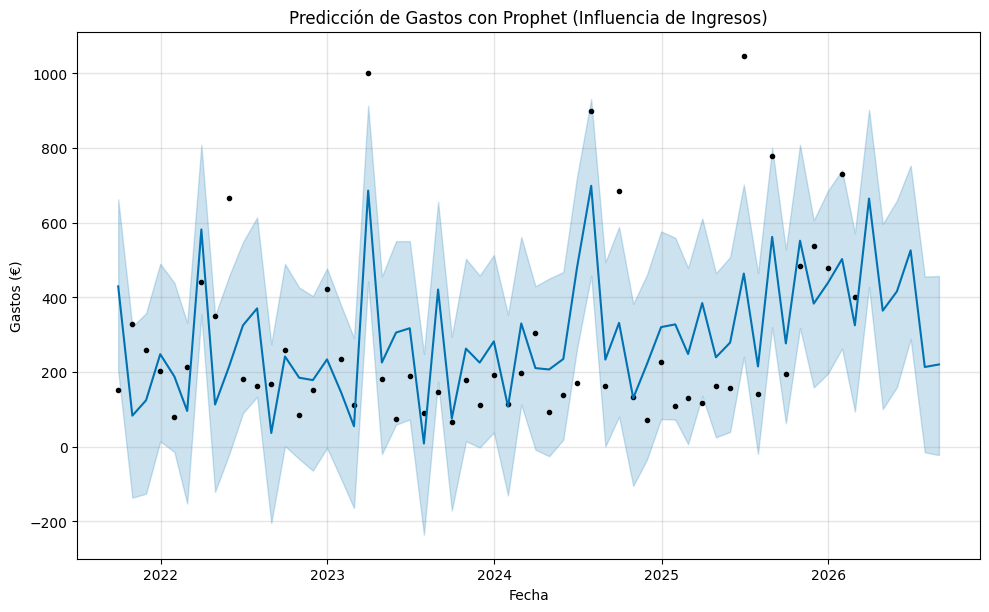

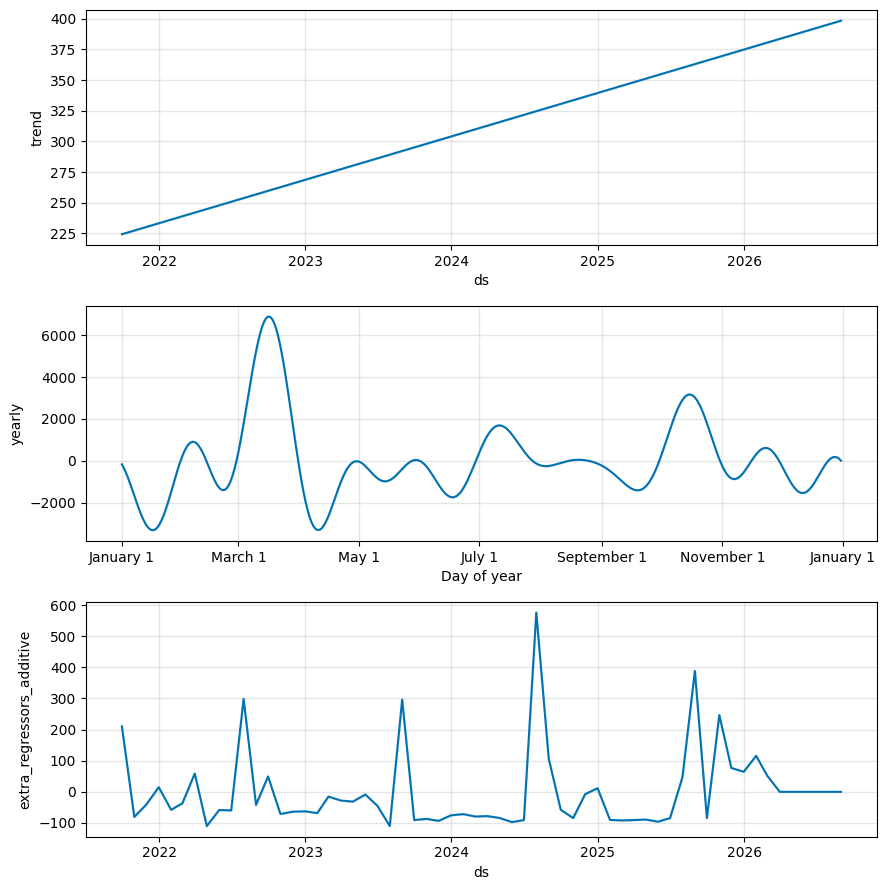

In [10]:
# Plot principal (Puntos negros = Datos Reales, Línea Azul = Predicción)
fig1 = model.plot(forecast)
plt.title('Predicción de Gastos con Prophet (Influencia de Ingresos)')
plt.xlabel('Fecha')
plt.ylabel('Gastos (€)')
plt.show()

# Desglose de Componentes (Tendencia, Estacionalidad Anual y Efecto del Ingreso)
fig2 = model.plot_components(forecast)
plt.show()